-9.0


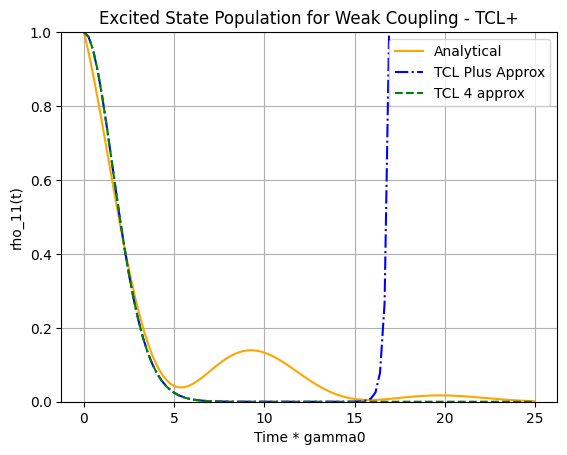

In [51]:
# prompt: simple differential equation solver for the equation gamma(t)c_1 = c_1 dot, where i can define the gamma function however i want. solve it as efficiently as possible - use whatever packages you need to do so

import numpy as np
from scipy.integrate import solve_ivp

def solve_plus(gamma_function, initial_condition, time_span):
  """
  Solves the differential equation gamma(t) * c_1 = dc_1/dt.

  Args:
    gamma_function: A function that takes time (t) as input and returns the value of gamma(t).
    initial_condition: The initial value of c_1 at t=0.
    time_span: A tuple (t_min, t_max) representing the time interval over which to solve the equation.

  Returns:
    A tuple containing two NumPy arrays: time points and the corresponding values of c_1(t).
  """

  def differential_equation(t, c1):
    return gamma_function(t) * c1

  # Use solve_ivp for efficient solution
  solution = solve_ivp(differential_equation, time_span, [initial_condition], dense_output=True)

  # Get the time points and the solution at those points
  t = np.linspace(time_span[0], time_span[1], 100)  # Adjust the number of points as needed
  c1 = solution.sol(t)[0]

  return t, c1

lam = 1
tauB = 1
gamma0 = 5/(tauB) #strong coupling
# Define the initial condition and time span
initial_c1 = 1.0
time_span = (0,5)

# Example usage:
def gamma_function_plus(t):
  return -lam**2*gamma0/2*(1-np.exp(-t/tauB)) - lam**4*gamma0/2*((1-np.exp(-t/tauB)) + 1/(2*tauB)*(np.sinh(t/tauB)-t/tauB)*np.exp(-t/tauB)) - lam**6/2*gamma0**3*(tauB*(-4*t*np.exp(t/tauB) + tauB*(2*np.exp(3*t/tauB) - 1) - 2*tauB*np.exp(t/tauB)) + (-2*t**2 - 2*t*tauB + tauB**2)*np.exp(2*t/tauB))*np.exp(-3*t/tauB)/16 \
  + lam**6*gamma0**3/16*(2*(4*tauB**2+2*tauB*t+t**2)*np.exp(-t/tauB)-tauB**2*np.exp(-2*t/tauB)-tauB*(7*tauB-2*t)) \
  + lam**6*gamma0**3/16*(-t**2 - 6*t*tauB - 12*tauB**2 + (t**2 - 6*t*tauB + 12*tauB**2)*np.exp(t/tauB))*np.exp(-t/tauB) \




def gamma_function(t):
  return -lam**2*gamma0/2*(1-np.exp(-t/tauB)) - lam**4*gamma0/2*((1-np.exp(-t/tauB)) + 1/(2*tauB)*(np.sinh(t/tauB)-t/tauB)*np.exp(-t/tauB))

def gamma_function_six(t):
  return +lam**2*gamma0/2*(1-np.exp(-t/tauB)) - lam**4*gamma0/2*((1-np.exp(-t/tauB)) + 1/(2*tauB)*(np.sinh(t/tauB)-t/tauB)*np.exp(-t/tauB)) - lam**6/2*gamma0**3*(tauB*(-4*t*np.exp(t/tauB) + tauB*(2*np.exp(3*t/tauB) - 1) - 2*tauB*np.exp(t/tauB)) + (-2*t**2 - 2*t*tauB + tauB**2)*np.exp(2*t/tauB))*np.exp(-3*t/tauB)/8




# Solve the equation
time_points, c1_values = solve_plus(gamma_function, initial_c1, time_span)
time_points_plus, c1_values_plus = solve_plus(gamma_function_plus, initial_c1, time_span)

time_points_six, c1_values_six = solve_plus(gamma_function_six, initial_c1, time_span)
#analytical for comparison
def analyticalFunction(t):
    strength = 1-2*lam**2*gamma0*tauB
    print(strength)

    s = np.sqrt(complex(strength))
    rho11 = 0
    if strength > 0:
        rho11 = np.exp(-t/tauB) * abs((np.cosh(t*s/(2*tauB)))+(1/s)*np.sinh(t*s/(2*tauB)))**2
    else:
        rho11 = np.exp(-t/tauB) * abs(np.cos(t*abs(s)/(2*tauB))+(1/((1j)*abs(s)))*np.sin(t*abs(s)/(2*tauB)))**2

    return rho11


# You can now further process or plot the results
import matplotlib.pyplot as plt

plt.plot(time_points*gamma0, analyticalFunction(time_points),color='orange',label='Analytical')
plt.plot(time_points*gamma0, c1_values_plus**2,color='blue',linestyle='dashdot',label='TCL Plus Approx')
plt.plot(time_points*gamma0, c1_values**2,color='green',linestyle='--',label='TCL 4 approx')
#plt.plot(time_points*gamma0, c1_values_six**2,color='red',linestyle=':',label='TCL 6 approx')

#plt.plot(time_points*gamma0,gamma_function(time_points)/gamma0,color='purple',linestyle = '--', label='gamma')
#plt.plot(time_points*gamma0,gamma_function_plus(time_points)/gamma0,color='red',linestyle = '--', label='gamma plus')
plt.legend()
plt.ylim(0,1)
plt.xlim()
plt.xlabel('Time * gamma0')
plt.ylabel('rho_11(t)')
plt.title('Excited State Population for Weak Coupling - TCL+')
plt.grid(True)
plt.show()




In [60]:
from sympy import symbols, Abs, exp, integrate

# define symbols
t, t1, t2, t3, t4, t5, t6, t7, tauB = symbols('t t1 t2 t3 t4 t5 t6 t7 tauB', real=True, positive=True)
'''
# define function
f = exp(-1/tauB * ((t - t2) + (t1 - t3) + (t4 - t5)))

# perform nested integration
result = integrate(
    f,
    (t5, 0, t4),
    (t4, 0, t3),
    (t3, 0, t2),
    (t2, 0, t1),
    (t1, 0, t)
)'''

f2 = exp(-1/tauB * ((t - t1) + (t2 - t3) + (t4 - t5) + (t6 - t7)))

# perform nested integration

result2 = integrate(
    f2,
    (t7, 0, t6),
    (t6, 0, t5),
    (t5, 0, t4),
    (t4, 0, t3),
    (t3, 0, t2),
    (t2, 0, t1),
    (t1, 0, t)
)

In [61]:
from sympy import simplify
print(simplify(result2))

tauB**4*(t**3 + 12*t**2*tauB + 60*t*tauB**2 + 120*tauB**3 + (t**3 - 12*t**2*tauB + 60*t*tauB**2 - 120*tauB**3)*exp(t/tauB))*exp(-t/tauB)/6


In [ ]:
print(simplify(result))

tauB**3*(tauB*(-tauB + (2*t - 7*tauB)*exp(2*t/tauB)) + 2*(t**2 + 2*t*tauB + 4*tauB**2)*exp(t/tauB))*exp(-2*t/tauB)/4
